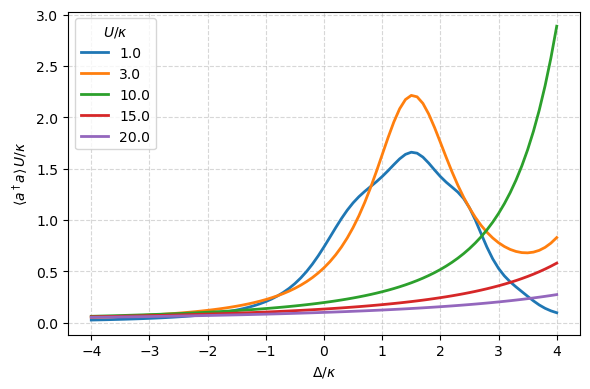

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import destroy, steadystate, expect

# Parameters
N = 80
kappa = 1.0
G_over_kappa = 1.0
G = G_over_kappa * kappa
U_list = np.array([1.0, 3.0, 10.0, 15.0, 20.0])
deltas = np.linspace(-4 * kappa, 4 * kappa, 81)

# Operators
a = destroy(N)
c_ops = [np.sqrt(kappa) * a]

# Hamiltonian builder
def build_hamiltonian(delta, U, G, a):
    return (-delta * a.dag() * a
            + 0.5 * U * a.dag()**2 * a**2
            + 0.5 * G * (a.dag()**2 + a**2))

# Steady-state photon number calculator
def compute_steady_state_n(U, deltas, G, a, c_ops):
    return np.array([
        expect(a.dag() * a, steadystate(build_hamiltonian(delta, U, G, a), c_ops))
        for delta in deltas
    ])

# Plotting
plt.figure(figsize=(6, 4))

for U in U_list:
    n_vals = compute_steady_state_n(U, deltas, G, a, c_ops)
    plt.plot(deltas / kappa, n_vals * U / kappa, lw=2, label=f"{U/kappa:.1f}")

plt.xlabel(r"$\Delta/\kappa$")
plt.ylabel(r"$\langle a^\dagger a\rangle\,U/\kappa$")
plt.legend(title=r"$U/\kappa$")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()
